### IMPORTS

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch 
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import DataLoader,Dataset
import matplotlib.pyplot as plt

### INITIAL SETUP

In [2]:
# For reproducibility (ensures same random initialization and data splits)
torch.manual_seed(42)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}") 

Using device: cuda


### DATA LOADING

In [5]:
df = pd.read_csv(r"/kaggle/input/fashionmnist/fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(60000, 785)

<function matplotlib.pyplot.show(close=None, block=None)>

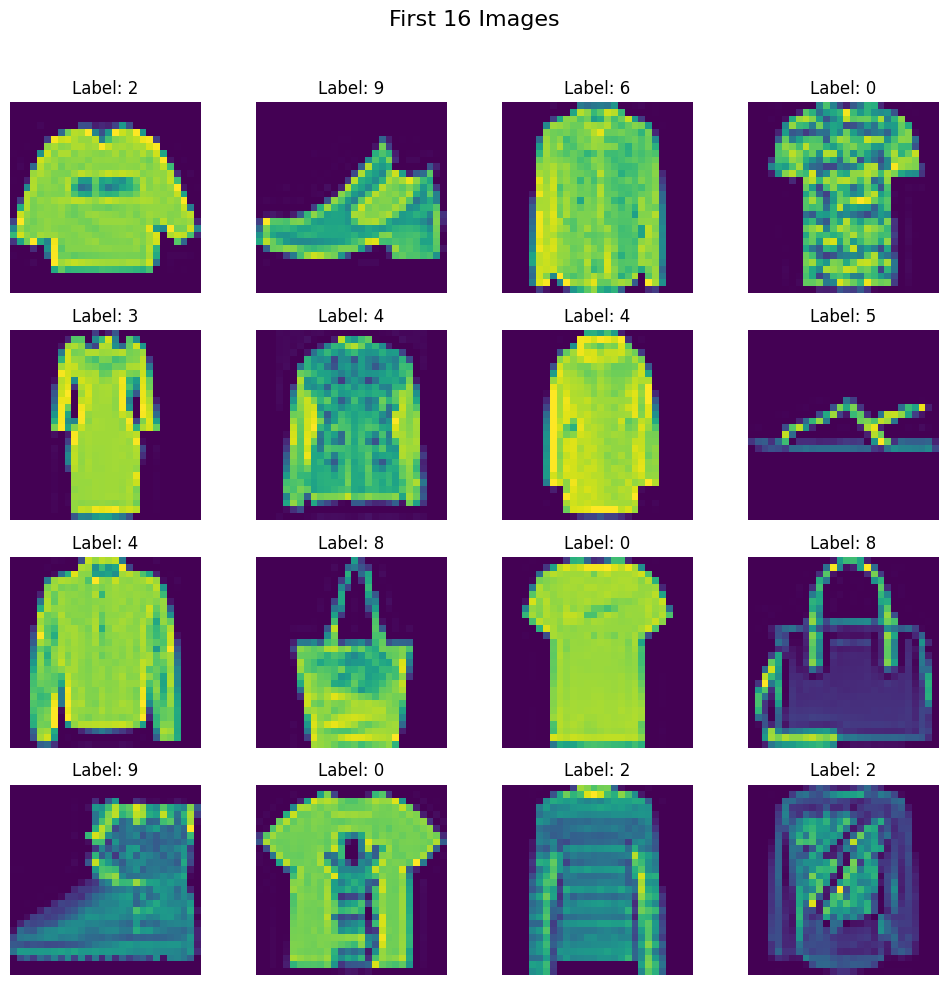

In [7]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Images",fontsize=16)

# Plot the first 16 images from the dataset

for i,ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28) # reshape t0 28x28
    ax.imshow(img) #Display the grayscale
    ax.axis('off') #Remove axis for a cleaner look 
    ax.set_title(f"Label: {df.iloc[i,0]}") # Show the label
    
plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.96]) # adjust layout to fit the title
plt.show

In [8]:
# Separate features (pixel values) and labels (classes)
x = df.iloc[:, 1:].values   # All columns except the first (images)
y = df.iloc[:, 0].values    # First column (labels)

In [9]:
# Check the number of unique labels (should be 10 for Fashion-MNIST)
df.iloc[:, 0].nunique()

10

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

### DATA PREPROCESSING

In [11]:
# Scaling the features
x_train = x_train/255.0
x_test = x_test/255.0 

### CUSTOM DATASET

In [12]:
class CustomDataset(Dataset):
    def __init__(self,features, labels) :
        # Convert to torch tensors and reshape features into image format (1, 28, 28)
        self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28) 
        self.labels = torch.tensor(labels, dtype= torch.long)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index) :
        return self.features[index], self.labels[index]

In [13]:
train_dataset = CustomDataset(x_train,y_train)
test_dataset = CustomDataset(x_test,y_test)

In [14]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False, pin_memory=True)

### MODEL DEFINITION

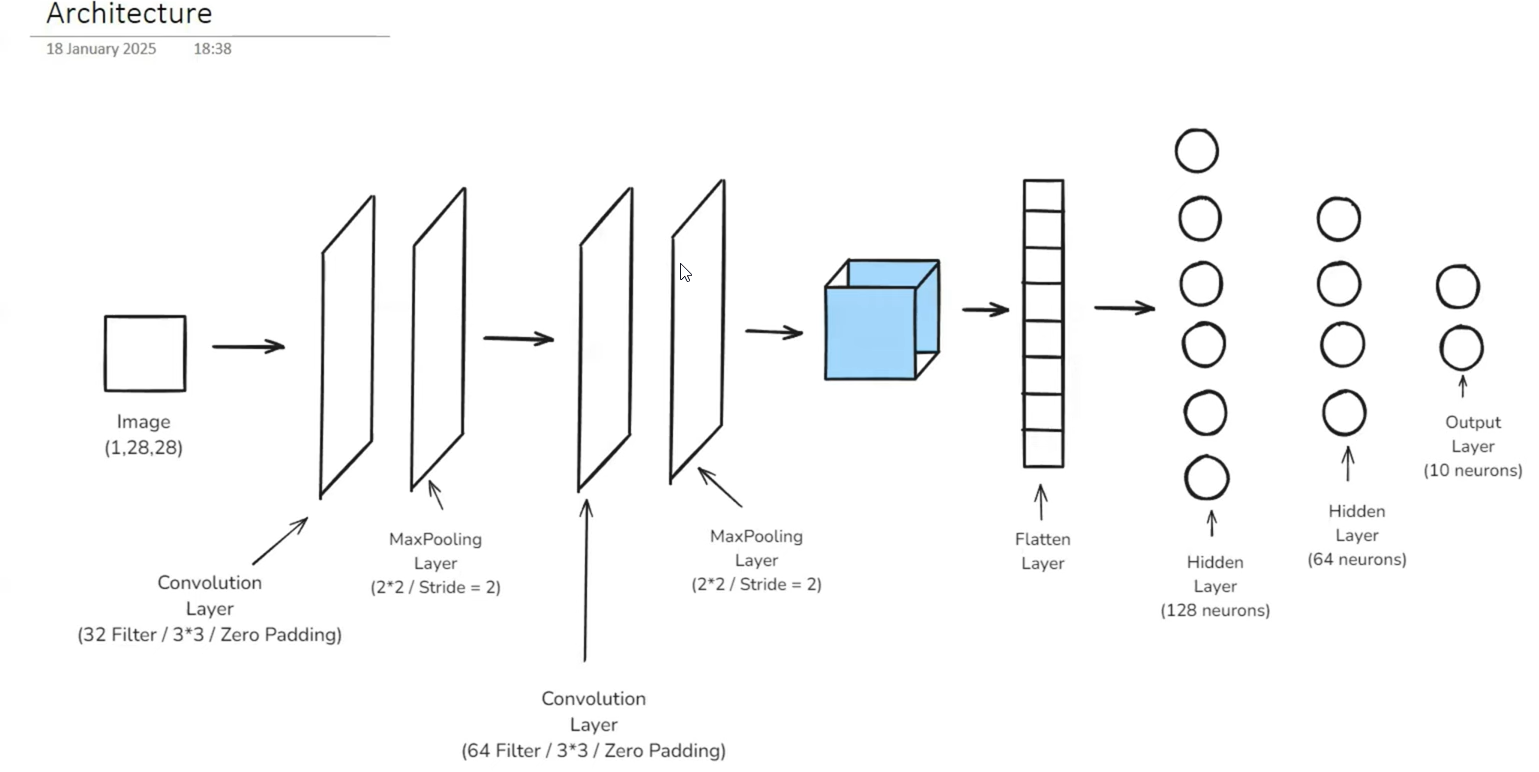

CNN Architecture:

image(1,28,28) -> conv(image[ filter = 3, num_filters = 32 , zero_padding = same ]) -> Pooling(conv[ stride = 2, filter = 2 ]) ->

conv(image[ filter = 3, num_filters = 64 , zero_padding = same ]) -> Pooling(conv[ stride = 2, filter = 2 ]) -> flatten(img) ->

1st_hidden_layer [flatten[ num_neurons = 128]] -> 2nd_hidden_layer [1st_hidden_layer[ num_neurons = 64]] -> 

Output (2nd_hidden_layer[ 10 ])

Size_Over_Time:

(1,28,28) -> conv -> (32,28,28) -> pooling -> (32,14,14) -> conv -> (64,14,14) -> pooling -> (64,7,7) -> flatten(64 * 7 * 7) -> (3136) -> ANN



In [15]:
class myNN(nn.Module):
    """Convolutional Neural Network for Fashion-MNIST classification."""
    def __init__(self, input_features) :
        super().__init__()
        
        # Feature extraction layers (CNN backbone)
        self.features = nn.Sequential(
            nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2,stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2 ,stride=2)
        )
        
        # Fully connected classifier(ANN)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(3136,128), # 64 feature maps * 7 * 7 = 3136
            nn.ReLU(),
            nn.Dropout(p=0.4),
            
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            
            nn.Linear(64,10)    # Output layer (10 classes)
            
        )
    
    def forward(self, x):
        """Forward propagation through the model."""
        x = self.features(x)
        x = self.classifier(x)
        
        return x
        

### TRAINING SETUP

In [16]:
learning_rate = 0.1
epochs = 100

In [19]:
# Initialize model
model = myNN(1)  # input_features = 1 channel for grayscale
model = model.to(device)

# Define loss function and optimizer
loss_function = nn.CrossEntropyLoss()
optomizer = optim.SGD(model.parameters(), lr= learning_rate, weight_decay=1e-4)

### TRAINING LOOP

In [20]:
for epoch in range(epochs):
    
    total_epoch_loss = 0
    for batch_features, batch_labels in train_loader:

        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        # Forward pass
        y_pred = model(batch_features)
        
        # Compute loss
        loss = loss_function(y_pred,batch_labels)
        
        # Zero out previous gradients
        optomizer.zero_grad()
        
        # Back Propagation
        loss.backward()
       
        # Update weights
        optomizer.step()
        
        total_epoch_loss = total_epoch_loss + loss.item()
    
    avg_loss = total_epoch_loss / len(train_loader)
    print(f"Epoch: {epoch},  loss: {avg_loss}")

Epoch: 0,  loss: 0.59556193711857
Epoch: 1,  loss: 0.4053039622356494
Epoch: 2,  loss: 0.3610361723452806
Epoch: 3,  loss: 0.3149780914398531
Epoch: 4,  loss: 0.2862909419834614
Epoch: 5,  loss: 0.26535029360776147
Epoch: 6,  loss: 0.24556354462355376
Epoch: 7,  loss: 0.23280414138610164
Epoch: 8,  loss: 0.22206182460362714
Epoch: 9,  loss: 0.20827691966605683
Epoch: 10,  loss: 0.2013303583074982
Epoch: 11,  loss: 0.19107172760988275
Epoch: 12,  loss: 0.18617575679036477
Epoch: 13,  loss: 0.18454905897472054
Epoch: 14,  loss: 0.17172026875211546
Epoch: 15,  loss: 0.16642835974150028
Epoch: 16,  loss: 0.15982811079919337
Epoch: 17,  loss: 0.15723273113556208
Epoch: 18,  loss: 0.15242525388440117
Epoch: 19,  loss: 0.15111085543036462
Epoch: 20,  loss: 0.14166751514468343
Epoch: 21,  loss: 0.1391899352185428
Epoch: 22,  loss: 0.13501561190001665
Epoch: 23,  loss: 0.13706669238752997
Epoch: 24,  loss: 0.12760861821169964
Epoch: 25,  loss: 0.1262305107304516
Epoch: 26,  loss: 0.124593952338

### EVALUATION

In [21]:
model.eval()    # Set model to evaluation mode

myNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [22]:
total = 0 
correct = 0

with torch.no_grad():
    for batch_features,batch_labels in test_loader:
        
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        y_pred = model(batch_features)      # Forward pass
        
        _, predicted  = torch.max(y_pred, 1)    # Get predicted labels
        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)  

0.9140833333333334
